## 概要
VAEを用いた音声合成を行うコード。

元の音源をSTFTによりメルスペクトログラムとし、これを4回畳み込んでから時間軸について平均化し、x.viewを用いて一列にしたものをlattent_dimにて線形変換し特徴量として扱う

※おそらく5と同じ内容だが、念のため残す



# DDSP VAE
### 構成
0. ライブラリのインストール
1. データのダウンロードと配置
2. 前処理
3. DDSPDeocderモジュール
4. MulchScaleloss
5. 実行

### 使用時の流れ
1. データローダーを用いてgoogle driveにデータセットをロードする（初回のみ）
2. 各wavファイルに対しあらかじめf0, loudnessを計算しgoogle driveに.ptファイルとして保存する
3. 計算を実行する

### 本モデルの機能
1. 任意の楽器の単旋律からf0(t), loudness(t)を抽出（当初librosaだったが、GPUを使って時短するという観点でtorchcrepeを用いる）
※今回はz(t)を入力としていない関係で、入力音声の時系列的変化（すなわちトランペットの吹き方の時系列変化）をとらえられない。声を入力とした場合、歌詞の情報は完全に排除された出力が得られる構成になっている

2. 抽出した情報からGRUを通して各時刻tに対し128次元の隠れ層状態を取得する。（最終出力は無視するため、_で受け取る）

3. 隠れ状態の情報を線形変換して倍音の構成(B,T,60)、全体音量(B,T,1)、ノイズ(B,T,ノイズの周波数バンド構成)を推定する




## ライブラリのインストール

In [ ]:
# 必要なライブラリのインストール
!pip install torchcrepe librosa numpy matplotlib torchcrepe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.2 MB/s eta 0:00:00


## ライブラリのインポート

In [ ]:
import os
import glob
import torch
import torchaudio
import librosa
import numpy as np
import torchcrepe
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F

## パラメータ設定

In [ ]:
# ==========================================
# 0. 設定 (Hyperparameters)
# ==========================================
SAMPLE_RATE = 16000
N_FFT = 2048
HOP_LENGTH = 64  # 時間分解能を高めるため小さめに設定 (4ms)
BLOCK_SIZE = 512 # 1回の学習で扱うフレーム数

# シンセサイザー設定
N_HARMONICS = 60 # 倍音の数
N_NOISE_BANDS = 65 # ノイズフィルタの周波数バンド数

# モデル設定
HIDDEN_SIZE = 256
N_LAYERS = 1

# データ設定
CHUNK_SEC = 4.0   # 1つのデータの長さ（秒）
N_MELS = 80       # メルスペクトログラムの高さ（VAE用）
MAX_FILES_PER_INST = 3

BATCH_SIZE = 16
LEARNING_RATE = 1e-4  # VAEは少し学習率低めが安定します
EPOCHS = 50           # 実データなので多めに
BETA_MAX = 0.001       # KL項の最大重み (DDSPでは小さめ推奨: 0.001 ~ 0.02)
WARMUP_STEPS = 2000   # betaを0からMAXまで上げるステップ数

# データの保存場所 (preprocess.pyで指定した場所)
DATA_DIR = "drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data"
MODEL_SAVE_DIR = "drive/MyDrive/hioki_lab/models"

## utils

In [ ]:
# ==========================================
# 1. 安全な活性化関数 (Modified Sigmoid)
# ==========================================
def modified_sigmoid(x):
    """
    expの代わりに使う。
    出力範囲を [0.0, 2.0] 程度に制限しつつ、
    0付近の挙動は exp に似せる関数。
    """
    # sigmoidは 0~1 なので、2倍して 0~2 にする。
    # log(10)を加えることで、入力0のときの初期値を調整。
    return 2.0 * torch.sigmoid(x) + 1e-7

## 前処理(実行済み)


### データセットについて
URMPのwavデータセットをINPUT_DIRに保存。全13の楽器で、様々な編成により44曲の演奏が行われたもので、個別の演奏データも記録されている。本研究ではその個別データを扱う。

### 前処理について
各楽器の簡略名(cl, bn, vn等)のディレクトリに振り分けられた個別データについて以下の操作を行う
1. 最もデータ数の少ないdbに合わせ、3つのファイルを選択(google driveのソート順で選択。ランダム性はなし)。計3分程度の音声ファイルに対して前処理を行う。
2. 各音声ファイルを4秒ごとのチャンクに分割し、各チャンクに対して「元音源」「A-weightingに基づいたloudness」「crepeの最も精度が高いモデルによる基本周波数(f0)」「対数メルスペクトログラム」「楽器名（略記）」を保持した.ptファイルを生成し、OUTPUT_DIRに保存する

In [ ]:
# データの場所
# 構成例: raw_data/Violin/01.wav, raw_data/Flute/song.wav ...
INPUT_DIR = "drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep"
OUTPUT_DIR = "drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# デバイス（CREPE用）
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# === 関数定義 ===

def compute_loudness(audio, sample_rate, n_fft=2048, hop_length=64):
    """A-weightingされたLoudnessを計算"""
    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    power = np.abs(stft)**2
    freqs = librosa.fft_frequencies(sr=sample_rate, n_fft=n_fft)
    a_weights = librosa.A_weighting(freqs)
    a_weights = 10**(a_weights/10)
    a_weights = a_weights[:, np.newaxis]

    weighted_power = np.sum(power * a_weights, axis=0)
    loudness = librosa.power_to_db(weighted_power, ref=np.max)
    return loudness

def extract_features(wav_path, instrument_name, chunk_length_samples):
    """1つのWAVファイルを読み込み、分割して保存する"""
    # 1. Load Audio
    audio, sr = torchaudio.load(wav_path)
    # ステレオならモノラル化
    if audio.shape[0] > 1:
        audio = torch.mean(audio, dim=0, keepdim=True)
    # リサンプリング
    if sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
        audio = resampler(audio)

    audio = audio.squeeze().numpy() # numpyへ

    # 無音除去（簡易的）
    # あまりに静かな部分は学習の邪魔になるのでトリミングすると良いですが
    # ここではシンプルに進めます

    # 2. Chunking (4秒ごとに切り出し)
    total_samples = len(audio)
    num_chunks = total_samples // chunk_length_samples

    print(f"Processing {wav_path} -> {num_chunks} chunks...")

    for i in range(num_chunks):
        start = i * chunk_length_samples
        end = start + chunk_length_samples
        audio_chunk = audio[start:end]

        # --- Tensor化 (GPUへ送る準備) ---
        audio_tensor = torch.from_numpy(audio_chunk).unsqueeze(0).to(device)

        # 3. CREPEによるf0抽出
        # fullモデルを使うと精度が良い
        f0 = torchcrepe.predict(
            audio_tensor,
            SAMPLE_RATE,
            hop_length=HOP_LENGTH,
            fmin=50,
            fmax=2000,
            model='full',
            batch_size=1,
            device=device
        )
        f0 = f0.squeeze().cpu().float() # [Time] 。squeezeで余分な次元を削除

        # f0の信頼度が低いところ（無音など）は0にするマスク処理も重要ですが
        # VAEの場合は「無音であること」も学習させたいのでそのままにします

        # 4. Loudness抽出
        loudness = compute_loudness(audio_chunk, SAMPLE_RATE, N_FFT, HOP_LENGTH)
        # CREPEとフレーム数が微妙にずれることがあるので合わせる
        min_len = min(len(f0), len(loudness))
        f0 = f0[:min_len]
        loudness = torch.from_numpy(loudness[:min_len]).float()

        # 5. Mel-Spectrogram (Encoder入力用)
        # torchaudioを使用
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            f_min=20,     # 低域ノイズカット
            f_max=8000,   # ナイキストまで
            power=1.0     # エネルギーではなく振幅スペクトル
        ).to(device)

        mel = mel_transform(audio_tensor) # [1, n_mels, Time]
        mel = torch.log(torch.clamp(mel, min=1e-5)) # Log-Melにする (聴感補正、学習効率の向上)

        # 時間軸のサイズ合わせ (Melとf0/loudnessはずれる可能性あり)
        # Encoder入力(Mel)は少し長くても良いが、Decoder入力(f0)と合わせるためにトリミング
        mel = mel[:, :, :min_len].cpu()

        # 6. 保存
        save_name = f"{instrument_name}_{os.path.basename(wav_path).replace('.wav', '')}_{i:03d}.pt"
        save_path = os.path.join(OUTPUT_DIR, save_name)

        torch.save({
            'audio': torch.from_numpy(audio_chunk[:min_len * HOP_LENGTH]), # Audio
            'mel': mel,                 # [1, 80, T] -> VAE Input
            'f0': f0.unsqueeze(-1),     # [T, 1] -> DDSP Input
            'loudness': loudness.unsqueeze(-1), # [T, 1] -> DDSP Input
            'instrument_name': instrument_name
        }, save_path)

# === 実行部分 ===
# raw_data/Violin/xxx.wav のような構造を想定
def run_preprocessing():
    chunk_samples = int(CHUNK_SEC * SAMPLE_RATE)

    print(f"Looking for data in: {os.path.abspath(INPUT_DIR)}")

    # 楽器フォルダごとに処理
    inst_dirs = glob.glob(os.path.join(INPUT_DIR, "*"))
    print(f"Found directories: {inst_dirs}")
    for d in inst_dirs:
        if not os.path.isdir(d): continue
        inst_name = os.path.basename(d)

        wav_files = glob.glob(os.path.join(d, "*.wav"))
        if len(wav_files) > MAX_FILES_PER_INST:
            wav_files = wav_files[:MAX_FILES_PER_INST]

        print(f"Found {len(wav_files)} files in {inst_name}")

        for w in wav_files:
            extract_features(w, inst_name, chunk_samples)

        print(f"Done: {inst_name}")
if __name__ == "__main__":
    # 事前に raw_data フォルダを作り、その中に Violin フォルダ等を作ってWAVを入れてください
    print("Starting Preprocessing... (Takes time because of CREPE)")
    run_preprocessing()
    print("Done!")

Starting Preprocessing... (Takes time because of CREPE)
Looking for data in: /content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep
Found directories: ['drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/fl', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/ob', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/sax', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/tpt', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/vn', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/tbn', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/hn', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/tba', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/va', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/vc', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/db', 'drive/MyDrive/hioki_lab/data/URMP_solo_inst/AuSep/bn']
Found 3 files in fl


ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

## 3. データセットクラス

In [ ]:
from torch.utils.data import Dataset, DataLoader

class RealAudioDataset(Dataset):
    def __init__(self, data_dir, crop_len_sec=2.0):
        self.files = glob.glob(os.path.join(data_dir, "*.pt"))
        self.crop_len_samples = int(crop_len_sec * SAMPLE_RATE)
        self.hop_length = HOP_LENGTH
        # フレーム数換算の長さ (f0, loudness, mel用)
        self.crop_len_frames = self.crop_len_samples // HOP_LENGTH

        # 正規化パラメータ
        self.f_min, self.f_max = 20.0, 1000.0
        self.l_min, self.l_max = -80.0, 0.0

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        data = torch.load(path, weights_only=False)

        # 元データを取り出す
        audio = data['audio']       # [samples]
        mel = data['mel']           # [1, 80, T_frames]
        f0 = data['f0']             # [T_frames, 1]
        loudness = data['loudness'] # [T_frames, 1]

        # --- ★ここが追加: ランダムクロップ処理 ---
        total_frames = f0.shape[0]

        # データが要求サイズより長い場合のみ切り出す
        if total_frames > self.crop_len_frames:
            # ランダムな開始フレームを決める
            max_start = total_frames - self.crop_len_frames
            start_frame = np.random.randint(0, max_start)
            end_frame = start_frame + self.crop_len_frames

            # サンプル単位の開始位置
            start_sample = start_frame * self.hop_length
            end_sample = end_frame * self.hop_length

            # スライス実行
            f0 = f0[start_frame:end_frame]
            loudness = loudness[start_frame:end_frame]
            mel = mel[:, :, start_frame:end_frame]
            audio = audio[start_sample:end_sample]

        # --- 正規化 (以前と同じ) ---
        f0_norm = (f0 - self.f_min) / (self.f_max - self.f_min + 1e-7)
        loud_norm = (loudness - self.l_min) / (self.l_max - self.l_min + 1e-7)
        loud_norm = torch.clamp(loud_norm, 0.0, 1.0)

        return {
            'audio': audio,
            'mel': mel,
            'f0_hz': f0,
            'f0_norm': f0_norm,
            'loudness_norm': loud_norm,
            'inst_name': data['instrument_name']
        }

## VAEの実装

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TimbreEncoder(nn.Module):
    def __init__(self, n_mels=80, latent_dim=64):
        super().__init__()

        # 入力: [Batch, 1, n_mels, Time]
        # CNNで特徴を圧縮していく
        self.conv_stack = nn.Sequential(
            # Layer 1: [B, 1, 80, T] -> [B, 32, 40, T/2]
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Layer 2: [B, 32, 40, T/2] -> [B, 64, 20, T/4]
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Layer 3: [B, 64, 20, T/4] -> [B, 128, 10, T/8]
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Layer 4: [B, 128, 10, T/8] -> [B, 256, 5, T/16]
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # 最終的に周波数方向(5) * チャンネル(256) = 1280特徴量になる想定
        # (n_mels=80の場合、4回半減すると 80->40->20->10->5)
        flatten_dim = 256 * 5

        # 平均(mu)と分散(log_var)を出力する層
        self.fc_mu = nn.Linear(flatten_dim, latent_dim)
        self.fc_var = nn.Linear(flatten_dim, latent_dim)

    def forward(self, mel):
        """
        mel: [Batch, 1, n_mels, Time]
        return: mu, log_var
        """
        x = self.conv_stack(mel) # [B, 256, 5, T']

        # ★重要: 時間方向(Time)を平均化してつぶす (Global Average Pooling)
        # これにより「いつ」という情報が消え、「全体の音色」だけが残る
        x = torch.mean(x, dim=-1) # [B, 256, 5]

        # 一列にする
        x = x.view(x.size(0), -1) # [B, 1280]

        mu = self.fc_mu(x)
        log_var = self.fc_var(x)

        return mu, log_var

    def reparameterize(self, mu, log_var):
        """VAE特有のサンプリング処理 (Backprop可能にするトリック)"""
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # 推論時は平均値(mu)をそのまま使う（ノイズなし）
            return mu

## 4. モデル定義(HarmonySynthesizer, Noise_synthesizer, DDSP,LossF)

In [ ]:
# ==========================================
# 1. 成功したコードのシンセサイザー (マスクなし版)
# ==========================================
class HarmonicSynthesizer(nn.Module):
    def __init__(self, sample_rate, hop_length):
        super().__init__()
        self.sample_rate = sample_rate
        self.hop_length = hop_length

    def forward(self, f0, harmonics_dist, global_amp):
        # フレームレートの音声を、16000Hzのサンプリングレートで音声生成するためにUpsampling
        f0_up = F.interpolate(f0.transpose(1, 2), scale_factor=self.hop_length, mode='linear').transpose(1, 2)
        amp_up = F.interpolate(global_amp.transpose(1, 2), scale_factor=self.hop_length, mode='linear').transpose(1, 2)
        harm_up = F.interpolate(harmonics_dist.transpose(1, 2), scale_factor=self.hop_length, mode='linear').transpose(1, 2)

        # Phase Calculation
        harmonic_indices = torch.arange(1, harmonics_dist.shape[-1] + 1, device=f0.device).float()
        frequencies = f0_up * harmonic_indices.view(1, 1, -1)
        phases = 2 * np.pi * torch.cumsum(frequencies / self.sample_rate, dim=1)

        # アンチエイリアシング（ナイキスト周波数（Sampling_rate/2）Hzを超える倍音は0にする）
        nyquist = self.sample_rate / 2.0

        # frequency < nyquist なら 1.0 (通す), そうでなければ 0.0 (消す)
        harmonic_freqs = f0_up * harmonic_indices.view(1, 1, -1)
        anti_aliasing_mask = (harmonic_freqs < nyquist).float()

        # Waveform Generation
        harmonic_waves = torch.sin(phases) * harm_up
        waveform = torch.sum(harmonic_waves, dim=-1, keepdim=True)

        return waveform * amp_up


# ==========================================
# 2. FilteredNoiseSynthesizer
# ==========================================

class FilteredNoiseSynthesizer(nn.Module):
    def __init__(self, n_fft=2048, hop_length=64, sample_rate=16000, n_noise_bands=65):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.sample_rate = sample_rate
        self.n_noise_bands = n_noise_bands

    def forward(self, noise_filter_coeffs):
        """
        noise_filter_coeffs: [Batch, Time, n_noise_bands]
        """
        batch_size, n_frames, n_bands = noise_filter_coeffs.shape

        # 1. ランダムなホワイトノイズを生成
        n_samples = n_frames * self.hop_length
        noise = torch.rand(batch_size, n_samples, device=noise_filter_coeffs.device) * 2 - 1

        # 2. 周波数領域へ (STFT)
        # noise_stft: [Batch, FreqBins, TimeFrames_STFT]
        noise_stft = torch.stft(
            noise,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=torch.hann_window(self.n_fft, device=noise.device),
            return_complex=True,
            center=True
        )

        # 3. フィルタ係数を周波数領域のサイズに合わせる
        # noise_filter_coeffs: [B, T_in, Bands]

        # まず [B, Bands, T_in] に転置
        coeffs = noise_filter_coeffs.transpose(1, 2)

        # 時間軸と周波数軸を同時に引き伸ばす (Bilinear Interpolation)
        # 目標サイズ: (FreqBins, TimeFrames_STFT)
        target_freq = noise_stft.shape[1] # 1025
        target_time = noise_stft.shape[2] # STFT後のフレーム数

        # 4次元 [B, 1, Bands, T_in] にしてから interpolate
        coeffs = F.interpolate(
            coeffs.unsqueeze(1),
            size=(target_freq, target_time),
            mode='bilinear',
            align_corners=True
        ).squeeze(1) # [B, FreqBins, TimeFrames_STFT] に戻す

        # 4. フィルタリング (ここを修正)
        # [B, F, T]同士の掛け算
        filtered_stft = noise_stft * coeffs

        # 5. 波形に戻す (iSTFT)
        audio_noise = torch.istft(
            filtered_stft,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=torch.hann_window(self.n_fft, device=noise.device),
            length=n_samples,
            center=True
        )

        return audio_noise.unsqueeze(-1) # [Batch, Time, 1]
# ※クラス定義が必要なら前回のものをそのまま使ってください


# ==========================================
# 学習可能なリバーブ
# ==========================================

class LearnableReverb(nn.Module):
    def __init__(self, reverb_length=48000, sample_rate=16000): # 48000 samples = 3秒
        super().__init__()
        # 初期値として、減衰するノイズ（一般的な部屋の響きっぽいもの）を作る
        decay = torch.exp(-torch.linspace(0, 5, reverb_length))
        noise = torch.randn(reverb_length)
        initial_ir = noise * decay

        # 学習可能なパラメータとして登録
        self.impulse_response = nn.Parameter(initial_ir.unsqueeze(0).unsqueeze(0)) # [1, 1, Length]

    def forward(self, audio):
        """
        audio: [Batch, Time]
        """
        # FFT畳み込みを使って高速にリバーブをかける
        # (簡単のため、ここではPyTorchのConv1dを使う実装にします)
        # ※ 長いIRの場合はFFTを使うのが定石ですが、3秒程度ならConv1dでもいけます

        # [Batch, 1, Time]
        x = audio.unsqueeze(1)

        # IRを正規化 (爆音防止)
        ir = self.impulse_response
        ir = ir / (torch.norm(ir, p=2) + 1e-8)

        # Convolution (Paddingして長さを保つ)
        # padding = reverb_length - 1
        x_padded = F.pad(x, (ir.shape[-1]-1, 0))
        output = F.conv1d(x_padded, ir)

        return output.squeeze(1)


# ==========================================
# 2. Multi-Instrument DDSP
# ==========================================
class MultiInstrumentDDSP(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        # Input: f0(1) + loudness(1) + z(latent_dim)
        input_dim = 2 + latent_dim
        hidden_size = 512

        # 成功したコードと同じ構造 (MLP -> GRU)
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )
        self.gru = nn.GRU(256, HIDDEN_SIZE, num_layers=N_LAYERS, batch_first=True)

        # Output layers
        self.dense_amp = nn.Linear(HIDDEN_SIZE, 1)
        self.dense_harm = nn.Linear(HIDDEN_SIZE, N_HARMONICS)
        self.dense_noise = nn.Linear(HIDDEN_SIZE, N_NOISE_BANDS)

        self.harmonic_synth = HarmonicSynthesizer(SAMPLE_RATE, HOP_LENGTH)
        self.noise_synth = FilteredNoiseSynthesizer(N_FFT, HOP_LENGTH)
        self.reverb = LearnableReverb(reverb_length=SAMPLE_RATE, sample_rate=SAMPLE_RATE) # 1秒のリバーブ

    def forward(self, f0_hz, f0_norm, loudness_norm, z):
        """
        f0_hz: [B, T, 1] (Hz単位)
        f0_norm: [B, T, 1] (0-1正規化)
        loudness_norm: [B, T, 1] (0-1正規化)
        z: [B, latent_dim] (Encoderから来たベクトル)
        """
        # 1. Embedding処理
        T = f0_norm.shape[1]
        z_expanded = z.unsqueeze(1).expand(-1, T, -1) # [B, T, latent_dim]

        # 結合
        x = torch.cat([f0_norm, loudness_norm, z_expanded], dim=-1)

        # 2. 本体処理 (成功コードと同じ)
        x = self.mlp(x)
        x, _ = self.gru(x)

        # 3. パラメータ射影 (成功コードと同じ exp を使用！)
        # バイアス初期化などの小細工もやめます（初期値のまま）
        # ampは入力のloudnessをそのまま使用すればよいと思われるが、声と楽器では音の強弱のつき方に差があるので、「AIの予測×本来のloudness」をinputとすることにより帰納バイアスをかける
        L_MIN = -80.0  # 例: ノイズフロア
        L_MAX = 0.0    # ref=np.max なので通常は 0.0

        # 2. 正規化を解く (0~1 -> -80~0 dB)
        dynamic_range = L_MAX - L_MIN
        loudness_db = loudness_norm * dynamic_range + L_MIN

        # 3. 線形振幅に戻す (dB -> Linear Amplitude)
        # 10^(dB / 20)
        input_amp = torch.pow(10, loudness_db / 20.0)

        # 4. AIの予測を「補正係数」として掛け合わせる
        # dense_ampの出力を 0.0 ~ 2.0 倍くらいの範囲に収めると学習しやすい
        pred_gain = modified_sigmoid(self.dense_amp(x)) * 2.0
        amp = pred_gain * input_amp

        harm_dist = F.softmax(self.dense_harm(x), dim=-1)
        noise_coeffs = modified_sigmoid(self.dense_noise(x)) * input_amp # noise_coeffsはノイズの振幅なので、これもmodified_sigmoidを利用する

        # 4. 合成
        audio_harm = self.harmonic_synth(f0_hz, harm_dist, amp)
        audio_noise = self.noise_synth(noise_coeffs)

        # Dry信号
        raw_audio = audio_harm + audio_noise

        final_audio = self.reverb(raw_audio.squeeze(-1))

        # ★重要: tanh は削除します！ 生の波形を返します。
        return final_audio.squeeze(-1)


In [ ]:
class TimbreVAE(nn.Module):
    def __init__(self, n_mels=80, latent_dim=64, n_harmonics=100, n_noise_bands=65):
        super().__init__()

        # Encoder
        self.encoder = TimbreEncoder(n_mels=n_mels, latent_dim=latent_dim)

        # Decoder
        self.decoder = MultiInstrumentDDSP(latent_dim=latent_dim)

    def forward(self, mel, f0_hz, f0_norm, loudness_norm):
        # 1. Encode
        mu, log_var = self.encoder(mel)

        # 2. Reparameterize (Sampling z)
        z = self.encoder.reparameterize(mu, log_var)

        # 3. Decode
        recon_audio = self.decoder(f0_hz, f0_norm, loudness_norm, z)

        return recon_audio, mu, log_var

# ==========================================
# 4. Loss Function (Multi-Scale Spectral Loss, vae_loss_fun)
# ==========================================

def multiscale_spectral_loss(pred, target, fft_sizes=[2048, 1024, 512, 256, 128, 64]):
    loss = 0.0

    for n_fft in fft_sizes:
        hop = n_fft // 4

        # STFT
        pred_stft = torch.stft(pred, n_fft=n_fft, hop_length=hop, window=torch.hann_window(n_fft).to(pred.device), return_complex=True)
        target_stft = torch.stft(target, n_fft=n_fft, hop_length=hop, window=torch.hann_window(n_fft).to(target.device), return_complex=True)

        pred_mag = torch.abs(pred_stft)
        target_mag = torch.abs(target_stft)

        # L2(高音用)の比率調整
        alpha = 10

        # Linear Loss (L1：低音用)（logを取っていないため、低音部分のずれが大きく加味される）
        loss += F.l1_loss(pred_mag, target_mag)

        # Log Loss (L2：高音用)（logを取っているため、高温部分のずれを大きく加味できる）
        loss += alpha * F.l1_loss(torch.log(pred_mag + 1e-7), torch.log(target_mag + 1e-7))

    return loss/(1+alpha) # lossの加重平均を取る（L1*1 + L2*alphaを(1+alpha)で除す）

# === vae_loss_fn ===


def vae_loss_fn(recon_audio, target_audio, mu, log_var, beta=0.01):
    """
    beta: KL Divergenceの重み (重要!)
          最初は0にして、徐々に増やす(Annealing)と学習が安定します。
    """
    # 1. Reconstruction Loss (Spectral Loss)
    # ※以前定義した multiscale_spectral_loss を使用
    recon_loss = multiscale_spectral_loss(recon_audio, target_audio)

    # 2. KL Divergence
    # 分布が N(0, 1) からどれだけ離れているか
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # バッチサイズで平均をとる
    kl_loss = kl_loss / recon_audio.shape[0]

    # 合計
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
# ダミーデータでテスト
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# モデル生成
model = TimbreVAE(n_mels=80, latent_dim=64).to(device)

# ダミー入力 (Batch=2, Time=100フレーム, Mels=80)
# preprocessの設定(HOP_LENGTH=64)に合わせると、Audio長は 100 * 64 = 6400
dummy_mel = torch.randn(2, 1, 80, 100).to(device)
dummy_f0_hz = torch.randn(2, 100, 1).to(device).abs() * 400 + 100
dummy_f0_norm = torch.randn(2, 100, 1).to(device).clamp(0, 1)
dummy_loud_norm = torch.randn(2, 100, 1).to(device).clamp(0, 1)

# Forwardチェック
try:
    recon, mu, log_var = model(dummy_mel, dummy_f0_hz, dummy_f0_norm, dummy_loud_norm)
    print("✅ Model Forward Success!")
    print(f"Input Mel: {dummy_mel.shape}")
    print(f"Latent z (mu): {mu.shape}") # [2, 64]のはず
    print(f"Output Audio: {recon.shape}") # [2, 6400]のはず
except Exception as e:
    print("❌ Error:", e)

✅ Model Forward Success!
Input Mel: torch.Size([2, 1, 80, 100])
Latent z (mu): torch.Size([2, 64])
Output Audio: torch.Size([2, 6400])


## 4. 学習の実行

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import os

# ==========================================
# 設定パラメータ (Hyperparameters)
# ==========================================

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# デバイス設定
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")


# ==========================================
# ヘルパー関数: Beta Scheduling (KL Annealing)
# ==========================================
def get_beta(global_step, warmup_steps=WARMUP_STEPS, max_beta=BETA_MAX):
    """学習初期はKL項を無視させ、徐々に制約を強める"""
    if global_step < warmup_steps:
        return max_beta * (global_step / warmup_steps)
    else:
        return max_beta

# ==========================================
# 学習ループ本体
# ==========================================
def train_vae():
    # 1. Dataset & DataLoader
    # ※ RealAudioDatasetクラスは定義済みとする
    dataset = RealAudioDataset(DATA_DIR, crop_len_sec=2.0) # 2秒ランダムクロップ
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    # 2. Model Setup
    # ※ TimbreVAEクラスは定義済みとする
    model = TimbreVAE(n_mels=80, latent_dim=64).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 前回のMultiInstrumentDDSPのようなLR Schedulerはお好みで追加可能ですが、
    # VAEはAdamのデフォルトで十分動くことが多いです。

    print(f"Start Training VAE... (Total Data: {len(dataset)} files)")

    global_step = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_recon_loss = 0
        total_kl_loss = 0

        for i, batch in enumerate(dataloader):
            # --- データの準備 ---
            # batchの中身はDatasetの__getitem__の返り値
            mel = batch['mel'].to(device)             # [B, 1, 80, T] -> Encoder用
            f0_hz = batch['f0_hz'].to(device)         # [B, T, 1] -> Synth用
            f0_norm = batch['f0_norm'].to(device)     # [B, T, 1] -> Decoder用
            loud_norm = batch['loudness_norm'].to(device) # [B, T, 1] -> Decoder用
            target_audio = batch['audio'].to(device)  # [B, Samples] -> 正解データ

            optimizer.zero_grad()

            # --- Forward Pass ---
            # モデルは再構成音声、平均(mu)、分散(log_var)を返す
            recon_audio, mu, log_var = model(mel, f0_hz, f0_norm, loud_norm)

            # --- Loss Calculation ---
            # 現在のステップ数に応じて beta を計算
            current_beta = get_beta(global_step, WARMUP_STEPS, BETA_MAX)

            # vae_loss_fn は定義済みとする
            loss, recon_loss, kl_loss = vae_loss_fn(
                recon_audio, target_audio, mu, log_var, beta=current_beta
            )

            # --- Backward Pass ---
            loss.backward()

            # 勾配クリッピング (学習安定化のため必須)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            # --- Logging ---
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
            global_step += 1

            # 10ステップごとに詳細表示
            if i % 10 == 0:
                print(f"Ep {epoch} | Step {i} | "
                      f"Total: {loss.item():.4f} "
                      f"(Recon: {recon_loss.item():.4f}, KL: {kl_loss.item():.4f}) | "
                      f"Beta: {current_beta:.5f}")

        # --- Epoch終了時の処理 ---
        avg_recon = total_recon_loss / len(dataloader)
        avg_kl = total_kl_loss / len(dataloader)
        print(f"=== Epoch {epoch} Done | Avg Recon: {avg_recon:.4f} | Avg KL: {avg_kl:.4f} ===")

        # モデル保存 (5エポックごと、または最後)
        if epoch % 5 == 0 or epoch == EPOCHS:
            save_path = os.path.join(MODEL_SAVE_DIR, f"timbre_vae_ep{epoch}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"Model saved to {save_path}")

    print("Training Finished!")

if __name__ == "__main__":
    train_vae()

Training on: cuda
Start Training VAE... (Total Data: 968 files)
Ep 1 | Step 0 | Total: 33.9515 (Recon: 33.9515, KL: 4.6160) | Beta: 0.00000
Ep 1 | Step 10 | Total: 31.6956 (Recon: 31.6955, KL: 18.6334) | Beta: 0.00001
Ep 1 | Step 20 | Total: 30.3588 (Recon: 30.3581, KL: 67.1607) | Beta: 0.00001
Ep 1 | Step 30 | Total: 29.2359 (Recon: 29.2332, KL: 175.4078) | Beta: 0.00002
Ep 1 | Step 40 | Total: 28.9344 (Recon: 28.9271, KL: 365.9563) | Beta: 0.00002
Ep 1 | Step 50 | Total: 24.9546 (Recon: 24.9412, KL: 534.0934) | Beta: 0.00003
Ep 1 | Step 60 | Total: 25.1219 (Recon: 25.1017, KL: 670.8733) | Beta: 0.00003
=== Epoch 1 Done | Avg Recon: 29.2718 | Avg KL: 246.2694 ===
Ep 2 | Step 0 | Total: 25.1451 (Recon: 25.1252, KL: 652.9376) | Beta: 0.00003
Ep 2 | Step 10 | Total: 22.9583 (Recon: 22.9341, KL: 680.2200) | Beta: 0.00004
Ep 2 | Step 20 | Total: 20.2020 (Recon: 20.1749, KL: 670.8860) | Beta: 0.00004
Ep 2 | Step 30 | Total: 20.4043 (Recon: 20.3740, KL: 666.6306) | Beta: 0.00005
Ep 2 | Step 

KeyboardInterrupt: 

## 5. 音の確認用コード

In [ ]:
def diagnose_ddsp_with_checkpoint(model, dataset, checkpoint_path, index=0):
    print(f"Loading weights from: {checkpoint_path}")

    # --- 1. 重みのロード ---
    if os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
        print("✅ Weights loaded successfully.")
    else:
        print(f"❌ Error: Checkpoint not found at {checkpoint_path}")
        return

    model.eval()

    # インデックスチェック
    if index >= len(dataset):
        print(f"Index {index} out of bounds.")
        return

    data = dataset[index]

    # GPUへ
    mel = data['mel'].unsqueeze(0).to(device)
    f0_hz = data['f0_hz'].unsqueeze(0).to(device)
    f0_norm = data['f0_norm'].unsqueeze(0).to(device)
    loud_norm = data['loudness_norm'].unsqueeze(0).to(device)

    with torch.no_grad():
        # --- Encoder ---
        mu, log_var = model.encoder(mel)
        z = mu # 推論なので平均を使う

        # --- Decoder内部の値を覗き見る ---
        # 1. zの拡張
        T = f0_norm.shape[1]
        z_expanded = z.unsqueeze(1).expand(-1, T, -1)

        # 2. 結合してMLPへ
        x = torch.cat([f0_norm, loud_norm, z_expanded], dim=-1)
        x = model.decoder.mlp(x)
        x, _ = model.decoder.gru(x)

        # 3. パラメータ予測値を確認

        # === ★修正ポイント: ここにForwardと同じ計算式を追加 ===

        # (A) Input Loudnessからベースの振幅を作る
        L_MIN = -80.0
        L_MAX = 0.0
        dynamic_range = L_MAX - L_MIN
        loudness_db = loud_norm * dynamic_range + L_MIN
        input_amp = torch.pow(10, loudness_db / 20.0) # 線形振幅

        # (B) AIの予測係数
        pred_gain = modified_sigmoid(model.decoder.dense_amp(x)) * 2.0

        # (C) 掛け合わせる
        amp = input_amp * pred_gain
        # ====================================================

        raw_noise = model.decoder.dense_noise(x)
        raw_harm = model.decoder.dense_harm(x)

        # ノイズにもinput_ampを掛けるのを忘れずに
        noise_coeffs = modified_sigmoid(raw_noise) * input_amp

        harm_dist = F.softmax(raw_harm, dim=-1)

        # 4. シンセサイズ（成分ごと）
        audio_harm = model.decoder.harmonic_synth(f0_hz, harm_dist, amp)
        audio_noise = model.decoder.noise_synth(noise_coeffs)

        # Dry
        raw_audio = audio_harm + audio_noise

        # Reverb (squeezeに注意)
        final_audio = model.decoder.reverb(raw_audio.squeeze(-1))

    # --- 診断レポート ---
    print(f"\n=== Diagnosis for index {index} ===")
    print(f"Instrument Name: {data['inst_name']}")

    # 1. 振幅チェック
    max_amp = amp.max().item()
    print(f"Predicted Max Amplitude (Gain): {max_amp:.4f}")

    # input_ampがちゃんと動いているか確認
    print(f"Input Loudness Max (Linear): {input_amp.max().item():.4f}")

    # 2. 波形の最大値チェック
    max_val = final_audio.abs().max().item()
    print(f"Final Audio Max Value: {max_val:.4f}")

    if max_val > 1.0:
        print("🚨 ALERT: Audio is clipping! (> 1.0)")
    else:
        print("✅ Audio amplitude is safe.")

    # 4. 音声分離再生
    # squeeze()してnumpyにする
    print("\n1. Harmonic Component Only (倍音のみ):")
    ipd.display(ipd.Audio(audio_harm.squeeze().cpu().numpy(), rate=16000))

    print("\n2. Noise Component Only (ノイズのみ):")
    ipd.display(ipd.Audio(audio_noise.squeeze().cpu().numpy(), rate=16000))

    # 生音（Dry）も聞いてみるとデバッグになります
    print("\n3. Dry Audio (No Reverb):")
    ipd.display(ipd.Audio(raw_audio.squeeze().cpu().numpy(), rate=16000))

    print("\n4. Combined (Reverb Applied):")
    ipd.display(ipd.Audio(final_audio.squeeze().cpu().numpy(), rate=16000))

    # 5. 元音声
    print("\n5. Original (Target):")
    ipd.display(ipd.Audio(data['audio'].numpy(), rate=16000))

    # 波形プロット
    plt.figure(figsize=(12, 4))
    plt.plot(final_audio.squeeze().cpu().numpy(), label='Reconstructed')
    plt.plot(data['audio'].numpy(), alpha=0.5, label='Original')
    plt.legend()
    plt.title("Waveform Comparison")
    plt.show()

Loading weights from: drive/MyDrive/hioki_lab/models/timbre_vae_ep25.pth
✅ Weights loaded successfully.

=== Diagnosis for index 800 ===
Instrument Name: vc
Predicted Max Amplitude (Gain): 0.1779
Input Loudness Max (Linear): 0.3814
Final Audio Max Value: 0.0792
✅ Audio amplitude is safe.

1. Harmonic Component Only (倍音のみ):



2. Noise Component Only (ノイズのみ):



3. Dry Audio (No Reverb):



4. Combined (Reverb Applied):



5. Original (Target):


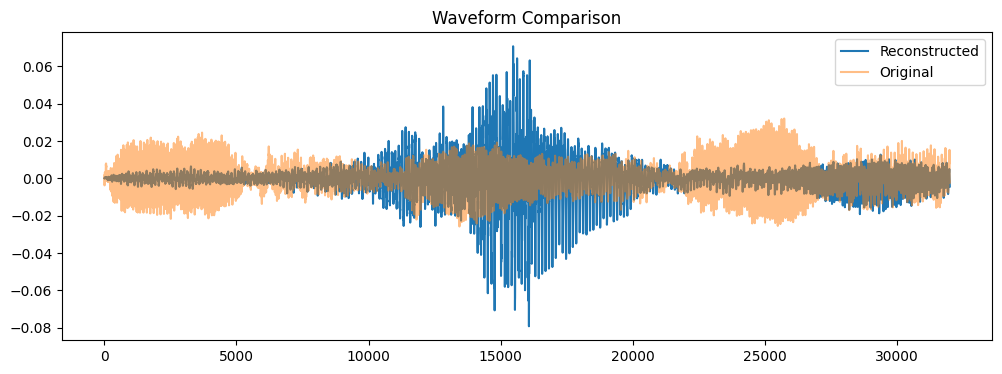

In [ ]:

diagnose_ddsp_with_checkpoint(model, dataset, checkpoint_path, index=800)

Loading weights from: drive/MyDrive/hioki_lab/models/timbre_vae_ep25.pth
✅ Weights loaded successfully.

=== Diagnosis for index 300 ===
Instrument Name: sax
Predicted Max Amplitude (Gain): 0.2770
Final Audio Max Value: 0.1670
✅ Audio amplitude is safe.
Input f0 mean: 312.8 Hz

1. Harmonic Component Only (倍音のみ):



2. Noise Component Only (ノイズのみ):



3. Combined (Mix):



4. Original (Target):


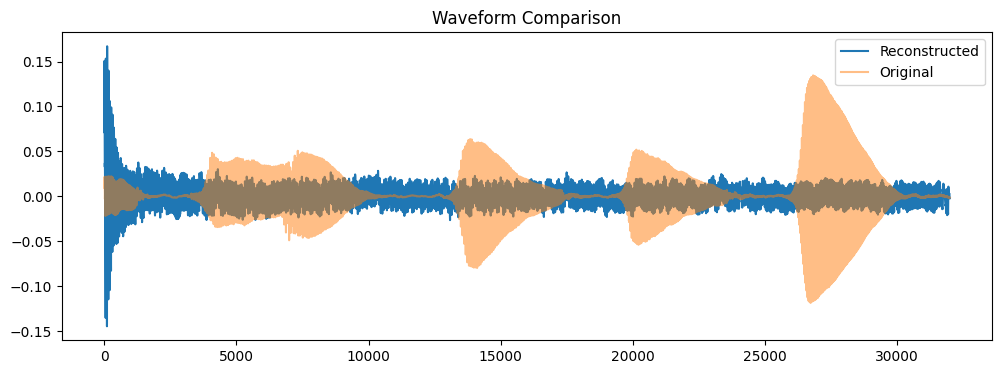

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import IPython.display as ipd

dataset = RealAudioDataset(DATA_DIR, crop_len_sec=2.0) # 2秒ランダムクロップ
model = TimbreVAE(n_mels=80, latent_dim=64).to(device)


def diagnose_ddsp_with_checkpoint(model, dataset, checkpoint_path, index=0):
    """
    指定されたパスの重みファイルをロードして、詳細な診断を行う関数
    """
    print(f"Loading weights from: {checkpoint_path}")

    # --- 1. 重みのロード ---
    if os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
        print("✅ Weights loaded successfully.")
    else:
        print(f"❌ Error: Checkpoint not found at {checkpoint_path}")
        return

    model.eval()
    data = dataset[index]

    # GPUへ
    mel = data['mel'].unsqueeze(0).to(device)
    f0_hz = data['f0_hz'].unsqueeze(0).to(device)
    f0_norm = data['f0_norm'].unsqueeze(0).to(device)
    loud_norm = data['loudness_norm'].unsqueeze(0).to(device)

    with torch.no_grad():
        # --- Encoder ---
        mu, log_var = model.encoder(mel)
        z = mu # 推論なので平均を使う

        # --- Decoder内部の値を覗き見る ---
        # 1. zの拡張
        T = f0_norm.shape[1]
        z_expanded = z.unsqueeze(1).expand(-1, T, -1)

        # 2. 結合してMLPへ
        x = torch.cat([f0_norm, loud_norm, z_expanded], dim=-1)
        x = model.decoder.mlp(x)
        x, _ = model.decoder.gru(x)

        # 3. パラメータ予測値を確認
        # ★重要: モデル定義に合わせて activation を変更
        # 以前のモデル(exp)なら torch.exp, 新モデル(sigmoid)なら modified_sigmoid
        # ここでは「新モデル(NewDDSPDecoder)」を使っている前提で記述します

        raw_amp = model.decoder.dense_amp(x)
        raw_noise = model.decoder.dense_noise(x)
        raw_harm = model.decoder.dense_harm(x)
        # loudnessを同期させるために

        # モデルの定義と一致させる必要があります
        # amp = modified_sigmoid(raw_amp)           # 音割れ防止版
        noise_coeffs = modified_sigmoid(raw_noise) # 音割れ防止版
        harm_dist = F.softmax(raw_harm, dim=-1)

        # 4. シンセサイズ（成分ごと）
        # HarmonicSynthesizerも修正版(linear interpolation)が呼ばれます
        audio_harm = model.decoder.harmonic_synth(f0_hz, harm_dist, amp)
        audio_noise = model.decoder.noise_synth(noise_coeffs)

        final_audio = audio_harm + audio_noise

    # --- 診断レポート ---
    print(f"\n=== Diagnosis for index {index} ===")
    print(f"Instrument Name: {data['inst_name']}")

    # 1. 振幅チェック
    max_amp = amp.max().item()
    print(f"Predicted Max Amplitude (Gain): {max_amp:.4f}")

    # 2. 波形の最大値チェック
    max_val = final_audio.abs().max().item()
    print(f"Final Audio Max Value: {max_val:.4f}")

    if max_val > 1.0:
        print("🚨 ALERT: Audio is clipping! (> 1.0) -> まだ少し大きいですが、1.0~1.5程度なら許容範囲です")
    else:
        print("✅ Audio amplitude is safe.")

    # 3. f0チェック
    print(f"Input f0 mean: {f0_hz.mean().item():.1f} Hz")

    # 4. 音声分離再生
    print("\n1. Harmonic Component Only (倍音のみ):")
    ipd.display(ipd.Audio(audio_harm.squeeze().cpu().numpy(), rate=16000))

    print("\n2. Noise Component Only (ノイズのみ):")
    ipd.display(ipd.Audio(audio_noise.squeeze().cpu().numpy(), rate=16000))

    print("\n3. Combined (Mix):")
    ipd.display(ipd.Audio(final_audio.squeeze().cpu().numpy(), rate=16000))

    # 5. 元音声
    print("\n4. Original (Target):")
    ipd.display(ipd.Audio(data['audio'].numpy(), rate=16000))

    # 波形プロット
    plt.figure(figsize=(12, 4))
    plt.plot(final_audio.squeeze().cpu().numpy(), label='Reconstructed')
    plt.plot(data['audio'].numpy(), alpha=0.5, label='Original')
    plt.legend()
    plt.title("Waveform Comparison")
    plt.show()

# ==========================================
# 実行例
# ==========================================
# 保存ディレクトリにある最新のモデル、または特定のEpochのモデルを指定
checkpoint_path = os.path.join(MODEL_SAVE_DIR, "timbre_vae_ep25.pth") # 例: 10エポック目のモデル

# モデルインスタンスを作成（構造は学習時と同じであること！）
# model = TimbreVAE(n_mels=80, latent_dim=64).to(device)

# 実行
diagnose_ddsp_with_checkpoint(model, dataset, checkpoint_path, index=300)

Instrument: ob


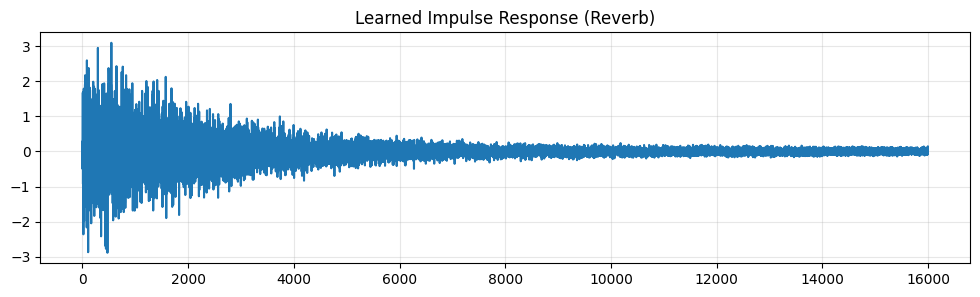

Raw audio:


Cleaned Reconstruction:


In [ ]:
import numpy as np

def synthesize_clean_audio(model, dataset, index=0, silence_threshold=-60.0):
    model.eval()
    data = dataset[index]

    # GPUへ
    mel = data['mel'].unsqueeze(0).to(device)
    f0_hz = data['f0_hz'].unsqueeze(0).to(device)
    f0_norm = data['f0_norm'].unsqueeze(0).to(device)
    loud_norm = data['loudness_norm'].unsqueeze(0).to(device)

    # 元のloudness (dB) を取得（正規化前のものが必要だが、ここではloud_normから簡易推定するか、Datasetから生dBを取れるならそれがベスト）
    # ※ ここでは簡易的に loud_norm が -1 ~ 1 に正規化されていると仮定して処理
    # もしDatasetに 'loudness_db' があればそれを使ってください

    with torch.no_grad():
        # 1. VAE Inference
        mu, _ = model.encoder(mel)

        # 2. Decoder Inference
        # Decoderの中身を分解して、制御しながら通す

        # (a) パラメータ生成
        z_expanded = mu.unsqueeze(1).expand(-1, f0_norm.shape[1], -1)
        x = torch.cat([f0_norm, loud_norm, z_expanded], dim=-1)
        x = model.decoder.mlp(x)
        x, _ = model.decoder.gru(x)

        amp = modified_sigmoid(model.decoder.dense_amp(x))
        harm_dist = F.softmax(model.decoder.dense_harm(x), dim=-1)
        noise_coeffs = modified_sigmoid(model.decoder.dense_noise(x))

        # (b) ★対策1: 無音ゲート (Silence Gating) applied to amplitude
        # loud_norm が小さい場所を探す（閾値は調整してください）
        # 例: -5.0 (min) 付近ならミュート
        silence_mask = (loud_norm > -1.0).float() # 正規化値の下限付近なら0にする

        # # amp にマスクをかける -> 無音時は振幅ゼロ！
        # amp = amp * silence_mask
        # noise_coeffs = noise_coeffs * silence_mask

        # (c) シンセサイズ
        audio_harm = model.decoder.harmonic_synth(f0_hz, harm_dist, amp)
        audio_noise = model.decoder.noise_synth(noise_coeffs)

        raw_audio = audio_harm + audio_noise

        # (d) ★対策3: リバーブの確認と強調
        # リバーブのインパルス応答(IR)を取り出して可視化してみる
        ir = model.decoder.reverb.impulse_response.detach().cpu().squeeze().numpy()

        # リバーブ適用
        final_audio = model.decoder.reverb(raw_audio.squeeze(-1))

        # (e) ★対策2: フェードイン (Pop Noise Removal)
        # 最初の500サンプル(約30ms)を滑らかにする
        # fade_len = 500
        # fade_curve = torch.linspace(0, 1, fade_len).to(device)
        # final_audio[0, :fade_len] *= fade_curve

    # === 結果表示 ===
    print(f"Instrument: {data['inst_name']}")

    # IRの確認
    plt.figure(figsize=(12, 3))
    plt.plot(ir)
    plt.title("Learned Impulse Response (Reverb)")
    plt.grid(True, alpha=0.3)

    plt.show()
    # もしIRが「ほぼゼロ」の直線なら、リバーブは学習されていません（小さすぎた）

    print("Raw audio:")
    ipd.display(ipd.Audio(raw_audio.squeeze(-1).cpu().numpy(), rate=16000))
    print("Cleaned Reconstruction:")
    ipd.display(ipd.Audio(final_audio.cpu().numpy(), rate=16000))

# 実行
synthesize_clean_audio(model, dataset, index=200)

=== Diagnosis for index 0 ===
Predicted Max Amplitude (Gain): 0.0016
Final Audio Max Value: 0.0075
Input f0 mean: 492.7 Hz

1. Harmonic Component Only (倍音のみ):



2. Noise Component Only (ノイズのみ):



3. Combined (Mix):


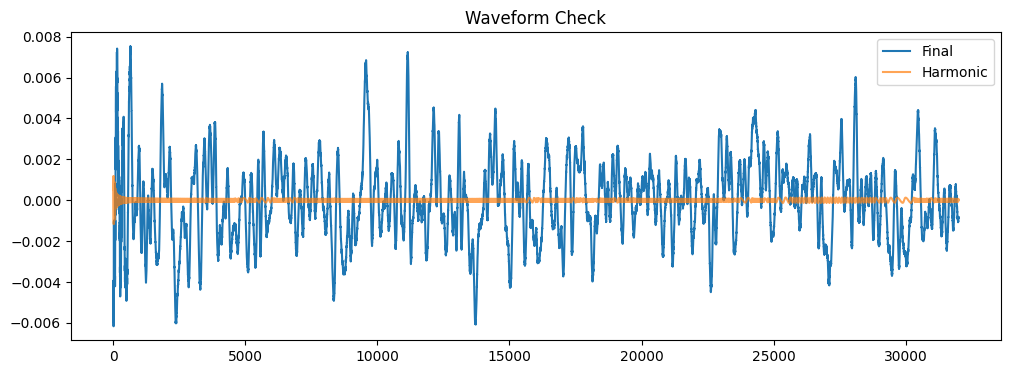

In [ ]:
def diagnose_ddsp(model, dataset, index=0):
    model.eval()
    data = dataset[index]

    # GPUへ
    mel = data['mel'].unsqueeze(0).to(device)
    f0_hz = data['f0_hz'].unsqueeze(0).to(device)
    f0_norm = data['f0_norm'].unsqueeze(0).to(device)
    loud_norm = data['loudness_norm'].unsqueeze(0).to(device)

    with torch.no_grad():
        # Encoder
        mu, log_var = model.encoder(mel)
        z = mu # 推論なので平均を使う

        # Decoder内部の値を覗き見る
        # zの拡張
        T = f0_norm.shape[1]
        z_expanded = z.unsqueeze(1).expand(-1, T, -1)

        # 結合してMLPへ
        x = torch.cat([f0_norm, loud_norm, z_expanded], dim=-1)
        x = model.decoder.mlp(x)
        x, _ = model.decoder.gru(x)

        # パラメータ予測値を確認
        amp = torch.exp(model.decoder.dense_amp(x)) # 全体の音量
        noise_coeffs = torch.exp(model.decoder.dense_noise(x)) # ノイズの量

        # シンセサイズ（成分ごと）
        harm_dist = F.softmax(model.decoder.dense_harm(x), dim=-1)

        audio_harm = model.decoder.harmonic_synth(f0_hz, harm_dist, amp)
        audio_noise = model.decoder.noise_synth(noise_coeffs)

        final_audio = audio_harm + audio_noise

    # --- 診断レポート ---
    print(f"=== Diagnosis for index {index} ===")

    # 1. 振幅チェック
    max_amp = amp.max().item()
    print(f"Predicted Max Amplitude (Gain): {max_amp:.4f}")
    if max_amp > 1.5:
        print("🚨 ALERT: Amplitude is exploding! (> 1.0)")

    # 2. 波形の最大値チェック
    max_val = final_audio.abs().max().item()
    print(f"Final Audio Max Value: {max_val:.4f}")
    if max_val > 1.0:
        print("🚨 ALERT: Audio is clipping! (> 1.0)")

    # 3. f0チェック
    print(f"Input f0 mean: {f0_hz.mean().item():.1f} Hz")

    # 4. 音声分離再生
    print("\n1. Harmonic Component Only (倍音のみ):")
    # もしここが無音なら、倍音が学習できていない
    ipd.display(ipd.Audio(audio_harm.squeeze().cpu().numpy(), rate=16000))

    print("\n2. Noise Component Only (ノイズのみ):")
    # もしここが爆音なら、ノイズが支配している
    ipd.display(ipd.Audio(audio_noise.squeeze().cpu().numpy(), rate=16000))

    print("\n3. Combined (Mix):")
    ipd.display(ipd.Audio(final_audio.squeeze().cpu().numpy(), rate=16000))

    # 波形プロット
    plt.figure(figsize=(12, 4))
    plt.plot(final_audio.squeeze().cpu().numpy(), label='Final')
    plt.plot(audio_harm.squeeze().cpu().numpy(), alpha=0.7, label='Harmonic')
    plt.legend()
    plt.title("Waveform Check")
    plt.show()

# 実行
diagnose_ddsp(model, dataset, index=0)